In [61]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder

## Dataset Preparation

In [62]:
data_dir = "../data/train"
dataset = ImageFolder(data_dir)

print("Number of images:", len(dataset))
print("Classes:", dataset.classes)
print("Class mapping:", dataset.class_to_idx)

Number of images: 25000
Classes: ['cat', 'dog']
Class mapping: {'cat': 0, 'dog': 1}


### Image Preprocessing

In [63]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [64]:
image, label = dataset[0]

print("Image type:", type(image))
print("Label:", label)

Image type: <class 'PIL.Image.Image'>
Label: 0


### Dataset Split

In [65]:
from torch.utils.data import random_split

In [66]:
##       train_size,               val_size,             test_size
size = [int(.8 *len(dataset)), int(.1*len(dataset)), int(.1*len(dataset))]

train_subset, val_subset, test_subset = random_split(
    dataset,
    size,
    generator=torch.Generator().manual_seed(42)
)
print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Test images:", len(test_subset))

Training images: 20000
Validation images: 2500
Test images: 2500


### Apply Transforms

In [67]:
from torch.utils.data import Subset

train_dataset_full = ImageFolder(
    data_dir,
    transform=train_transform
)

eval_dataset_full = ImageFolder(
    data_dir,
    transform= val_transform
)

train_dataset = Subset(train_dataset_full, train_subset.indices)
val_dataset = Subset(eval_dataset_full, val_subset.indices)
test_dataset = Subset(eval_dataset_full, test_subset.indices)

In [68]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label:", label)

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 1


### DataLoaders

In [69]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size
)

In [70]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


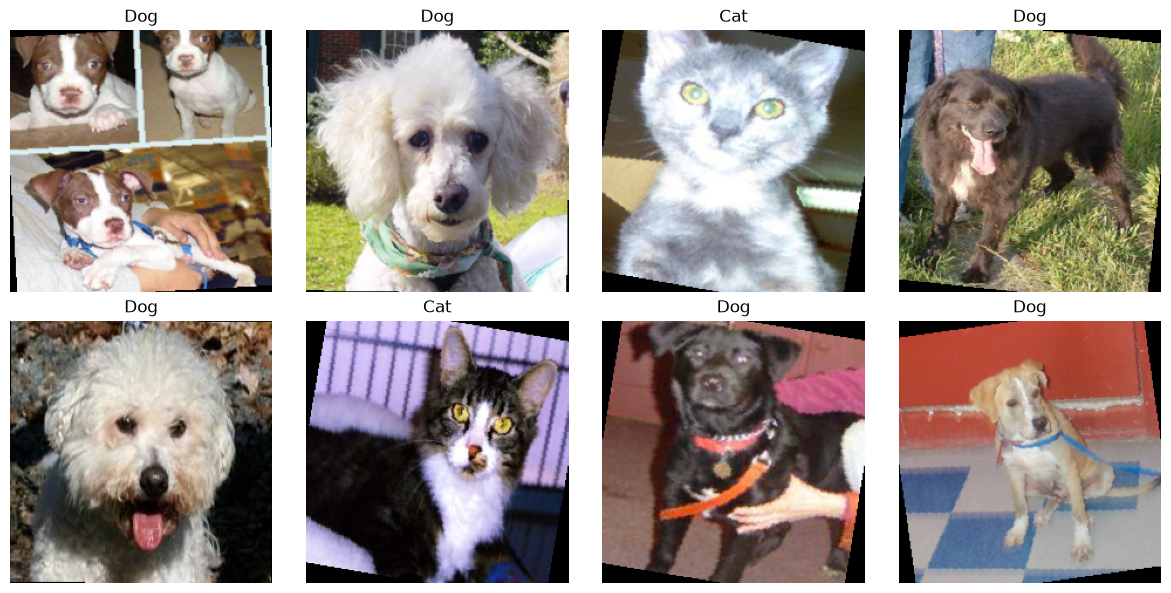

In [71]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0)
    ax.imshow(image)
    ax.set_title("Cat" if labels[i] == 0 else "Dog")
    ax.axis("off")

plt.tight_layout()
plt.show()

## CNN Model

In [72]:
import torch.nn as nn

In [73]:
class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            #input 3 x 224 x 224
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 32 x 112 x 122
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 64 X 56 x 56
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          

            # 128 x 28 x 28
            nn.AdaptiveAvgPool2d((4,4))
            # 128 x 4 x 4
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),

            # 128 × 4 × 4 = 2048
            nn.Linear(128*4*4, 128),
            nn.ReLU(),

            nn.Dropout(.5),

            # Binary classification
            nn.Linear(128, 1)
        )

    def forward(x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [59]:
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CatDogCNN()
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters())

In [60]:
print(model)

total_params = sum(p.numel() for p in model.parameters())

print("Total parameters:", total_params)

CatDogCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)
Total parameters: 355649
